In [ ]:
import os
os.environ["KERAS_BACKEND"] = "torch"

In [ ]:
# Standard library imports
import random
import warnings
from pathlib import Path

# Data handling and visualization imports
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Deep learning framework imports - PyTorch and Keras
import torch
from torch.utils.data import Dataset, DataLoader
import keras
from keras import layers

# Cats vs dogs classification

## Introduction

This project addresses a classic binary image classification problem: distinguishing between images of cats and dogs. The goal of this initial phase is to build a simple, working end-to-end pipeline - from raw images to a trained classifier with basic evaluation.

The project starts intentionally simple: a small convolutional neural network trained from scratch on a subset of the data, to establish a working baseline. Once this baseline is validated end-to-end, the project will be extended in later iterations.

## 1. Environment Setup

Before working with the data, we configure the Keras backend to use PyTorch, set random seeds for reproducibility across all libraries, and select the available compute device (GPU if available, otherwise CPU).

In [ ]:
warnings.filterwarnings("ignore") # Ignore warnings for cleaner output

In [ ]:
SEED = 42 # Master seed for all random operations

In [ ]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED) # PyTorch's random module for CPU
keras.utils.set_random_seed(SEED) # Keras's global random seed

In [ ]:
# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## 2. Dataset Overview

We use the official Microsoft "Kaggle Cats and Dogs" dataset, containing approximately 25,000 images split evenly between two classes: **Cat** and **Dog**. The dataset is downloaded directly via `keras.utils.get_file`, which handles both the download and extraction of the archive.

In [ ]:
# Download the official Microsoft Cats vs Dogs dataset
dataset_url = "https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip"

archive_path = keras.utils.get_file(
    fname="kagglecatsanddogs_5340.zip",
    origin=dataset_url,
    extract=True
)

# Define the base directory where images are stored
data_dir = Path(archive_path) / "PetImages"

In [ ]:
print(f"Dataset extracted to: {data_dir}")
print(f"Cat images: {len(list((data_dir / 'Cat').glob('*.jpg')))}")
print(f"Dog images: {len(list((data_dir / 'Dog').glob('*.jpg')))}")

Dataset extracted to: /root/.keras/datasets/kagglecatsanddogs_5340_extracted/PetImages
Cat images: 12500
Dog images: 12500


### Data Cleaning

The raw dataset contains a small number of corrupted image files that are not valid JFIF-encoded JPEGs. These files can cause errors later during training, so we scan every image, verify its file signature, and remove any file that fails the check.

In [ ]:
# The dataset contains a few corrupted JFIF images - filter them out before use
num_skipped = 0
all_paths = []

for category in ("Cat", "Dog"):
    folder_path = data_dir / category
    folder_files = list(folder_path.glob("*.jpg"))
    all_paths.extend(folder_files)

    for i, fname in enumerate(folder_files):
        try:
            with open(fname, "rb") as f:
                is_jfif = b"JFIF" in f.peek(10)
            if not is_jfif:
                num_skipped += 1
                os.remove(fname)
        except Exception:
            num_skipped += 1
            os.remove(fname)

        if (i + 1) % 2000 == 0:
            print(f"{category}: checked {i + 1}/{len(folder_files)} images")

print(f"Deleted {num_skipped} corrupted images")

Cat: checked 2000/12500 images
Cat: checked 4000/12500 images
Cat: checked 6000/12500 images
Cat: checked 8000/12500 images
Cat: checked 10000/12500 images
Cat: checked 12000/12500 images
Dog: checked 2000/12500 images
Dog: checked 4000/12500 images
Dog: checked 6000/12500 images
Dog: checked 8000/12500 images
Dog: checked 10000/12500 images
Dog: checked 12000/12500 images
Deleted 1590 corrupted images


## 3. Exploratory Data Analysis (EDA)

With the dataset cleaned, we take a first look at the data: counting the total number of usable images and visually inspecting a random sample to confirm the images loaded correctly and look as expected.

In [ ]:
all_image_paths = (
    list((data_dir / 'Cat').glob('*.jpg')) +
    list((data_dir / 'Dog').glob('*.jpg'))
)

print(f"Total images found: {len(all_image_paths)}")

Total images found: 23410


Selected random image: /root/.keras/datasets/kagglecatsanddogs_5340_extracted/PetImages/Cat/1544.jpg


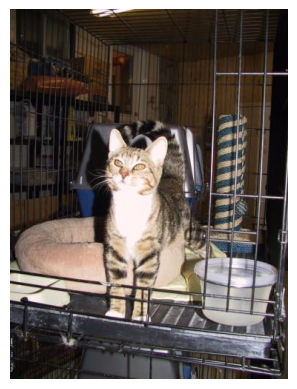

In [ ]:
random_image_path = random.choice(all_image_paths)
print(f"Selected random image: {random_image_path}")

image = Image.open(random_image_path)
plt.imshow(image)
plt.axis('off')
plt.show()

### 3.1 Class Distribution

We check how many images belong to each class after the data cleaning step, to confirm the dataset remains balanced between cats and dogs.

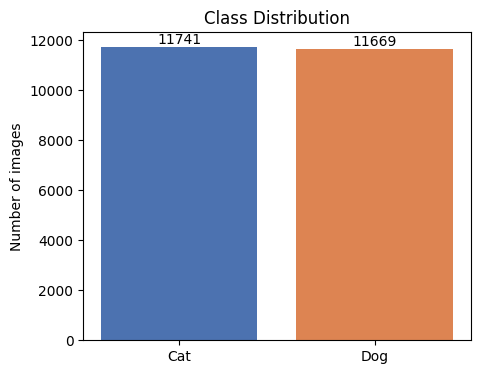

In [ ]:
cat_count = len(list((data_dir / "Cat").glob("*.jpg")))
dog_count = len(list((data_dir / "Dog").glob("*.jpg")))

plt.figure(figsize=(5, 4))
bars = plt.bar(["Cat", "Dog"], [cat_count, dog_count], color=["#4C72B0", "#DD8452"])
plt.title("Class Distribution")
plt.ylabel("Number of images")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, str(height), ha="center", va="bottom")

plt.show()

The dataset remains well balanced after cleaning: 11,741 cat images and 11,669 dog images, a difference of less than 1%. This means we can train and evaluate the model using plain accuracy as a metric, without needing class weighting or resampling techniques to handle imbalance.

### 3.2 Sample Images from Each Class

To get a better sense of the data, we display a grid of random sample images from both classes.

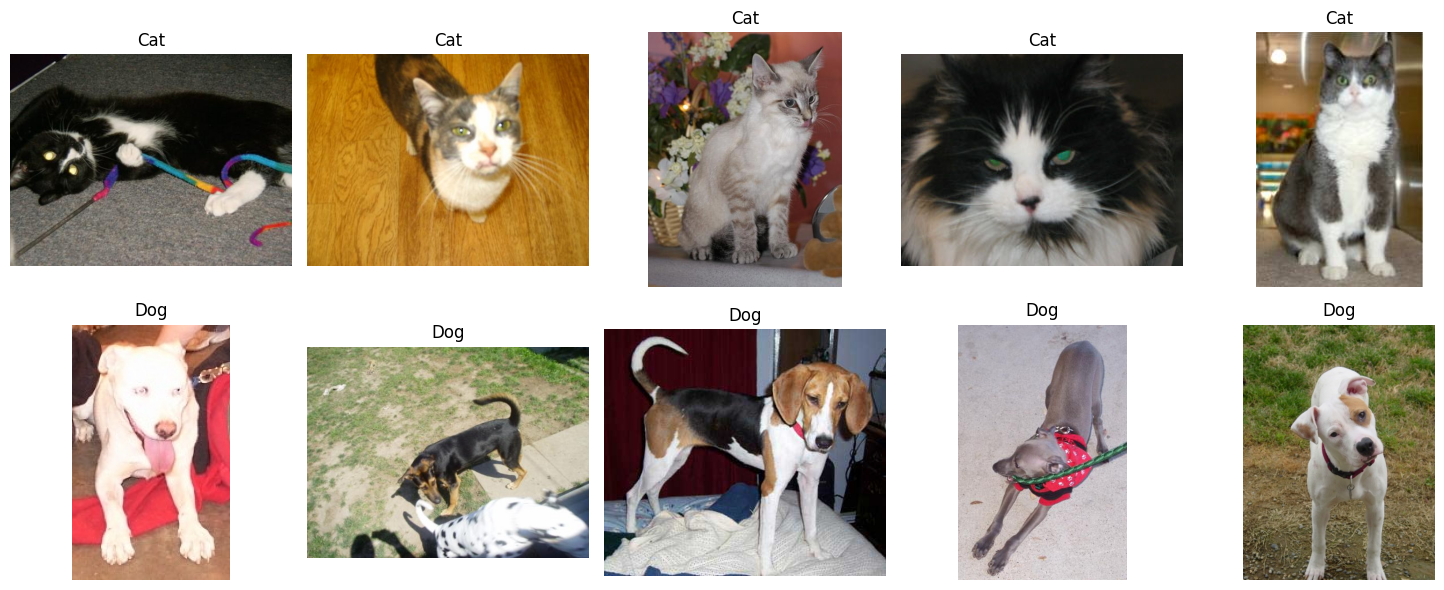

In [ ]:
cat_paths = list((data_dir / "Cat").glob("*.jpg"))
dog_paths = list((data_dir / "Dog").glob("*.jpg"))

sample_cats = random.sample(cat_paths, 5)
sample_dogs = random.sample(dog_paths, 5)
sample_images = sample_cats + sample_dogs
sample_labels = ["Cat"] * 5 + ["Dog"] * 5

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for ax, path, label in zip(axes.flatten(), sample_images, sample_labels):
    image = Image.open(path)
    ax.imshow(image)
    ax.set_title(label)
    ax.axis("off")

plt.tight_layout()
plt.show()

The sample images confirm that this is a real-world, unfiltered dataset: photos vary widely in pose, background, lighting, and framing (close-up portraits, full-body shots, indoor and outdoor scenes). This diversity is useful for training a model that generalizes well, but it also means the model cannot rely on consistent backgrounds or camera angles to make predictions.

### 3.3 Image Dimensions Analysis

Real-world images in this dataset vary in size. Before deciding on a fixed input size for the model, we sample a subset of images and inspect the distribution of their widths and heights.

Width  - min: 58, max: 500, mean: 412.7
Height - min: 50, max: 500, mean: 366.5


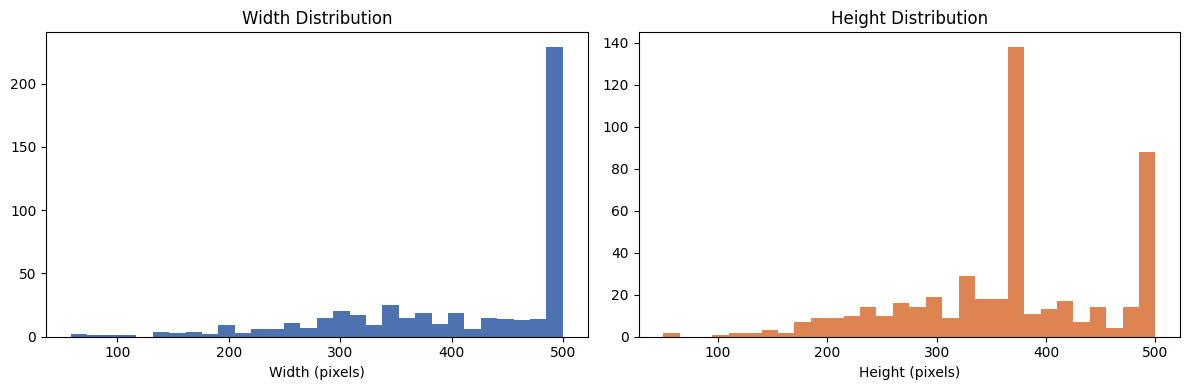

In [ ]:
sample_size = 500
sampled_paths = random.sample(all_image_paths, sample_size)

widths = []
heights = []

for path in sampled_paths:
    with Image.open(path) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)

widths = np.array(widths)
heights = np.array(heights)

print(f"Width  - min: {widths.min()}, max: {widths.max()}, mean: {widths.mean():.1f}")
print(f"Height - min: {heights.min()}, max: {heights.max()}, mean: {heights.mean():.1f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths, bins=30, color="#4C72B0")
axes[0].set_title("Width Distribution")
axes[0].set_xlabel("Width (pixels)")

axes[1].hist(heights, bins=30, color="#DD8452")
axes[1].set_title("Height Distribution")
axes[1].set_xlabel("Height (pixels)")

plt.tight_layout()
plt.show()

Image dimensions vary substantially: widths range from 58 to 500 pixels (mean 412.7) and heights from 50 to 500 pixels (mean 366.5). Both distributions are skewed toward the upper bound, with a large spike of images at exactly 500 pixels. This confirms that all images must be resized to a fixed input shape before being fed into the model, since a CNN requires consistent input dimensions.

### 3.4 Aspect Ratio Distribution

We also check the aspect ratio (width divided by height) of the sampled images, to see how far most images deviate from a square shape.

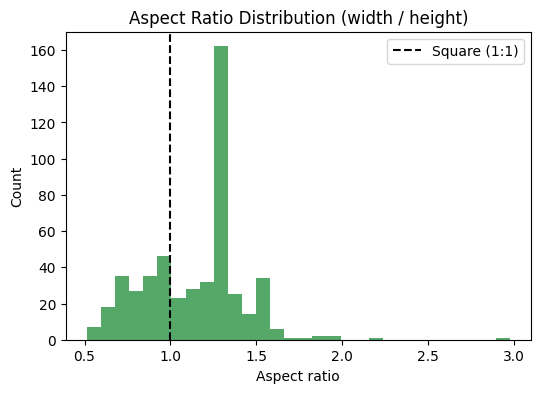

In [ ]:
aspect_ratios = widths / heights

plt.figure(figsize=(6, 4))
plt.hist(aspect_ratios, bins=30, color="#55A868")
plt.title("Aspect Ratio Distribution (width / height)")
plt.xlabel("Aspect ratio")
plt.ylabel("Count")
plt.axvline(1.0, color="black", linestyle="--", label="Square (1:1)")
plt.legend()
plt.show()

Most images have an aspect ratio between 0.5 and 2.0, with a clear peak around 1.3 to 1.4 (slightly wider than tall). Relatively few images are perfectly square (ratio of 1.0). Since the spread is moderate rather than extreme, a direct resize to a fixed square shape is a reasonable choice for this project, without requiring more complex padding or cropping strategies to preserve aspect ratio.

## References

**Dataset source:** [Microsoft "Kaggle Cats and Dogs" Dataset](https://www.microsoft.com/en-us/download/details.aspx?id=54765)